<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/07_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Unsupervised Learning

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Berbeda dengan regresi dan klasifikasi (supervised learning) di mana kita memiliki target prediksi yang jelas, pembelajaran tanpa pengawasan (unsupervised learning) berfokus pada penggalian pola dari data yang tidak memiliki label target. Tujuannya adalah untuk menemukan struktur tersembunyi, mengelompokkan data yang mirip, atau menyederhanakan kompleksitas data.

Teknik-teknik ini sering digunakan sebagai langkah pra-pemrosesan sebelum memasukkan data ke model prediktif, atau sebagai alat analisis untuk segmentasi pelanggan dan deteksi anomali.

### Topik yang Dibahas:
1. Analisis Komponen Utama (Principal Component Analysis / PCA)
2. Klastering K-Means (K-Means Clustering)
3. Menentukan Jumlah Klaster Optimal (Metode Elbow)
4. Klastering Hierarki (Hierarchical Clustering)
5. Klastering Berbasis Model (Gaussian Mixture Models)


***
## Setup: Import Library

Kita memuat modul standar untuk analisis matriks, pustaka visualisasi, dan algoritma klastering serta reduksi dimensi dari pustaka scikit-learn dan scipy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')

print("Modul Unsupervised Learning berhasil dimuat.")


Modul Unsupervised Learning berhasil dimuat.


***
## 1. Analisis Komponen Utama (PCA)

### Penjelasan Teori

Principal Component Analysis (PCA) adalah teknik reduksi dimensi. Saat kita berhadapan dengan dataset yang memiliki puluhan atau ratusan fitur numerik, sangat sulit untuk memvisualisasikannya atau melatih model secara efisien tanpa terkena kutukan dimensionalitas (curse of dimensionality).

PCA bekerja dengan mencari sumbu linier baru (komponen utama) yang memaksimalkan varians data. Komponen utama pertama adalah garis yang menangkap sebaran data paling luas. Komponen kedua tegak lurus (ortogonal) terhadap komponen pertama dan menangkap varians terbesar berikutnya.

Peringatan krusial pada PCA adalah variabel asli harus selalu distandarisasi (Standard Scaling) terlebih dahulu karena PCA sangat sensitif terhadap skala unit pengukuran. Jika tidak, variabel dengan angka jutaan akan mendominasi hasil komponen utama secara tidak proporsional.

Proporsi Varians yang Dijelaskan oleh setiap Komponen Utama:
[7.582e-01 2.096e-01 3.150e-02 7.000e-04]


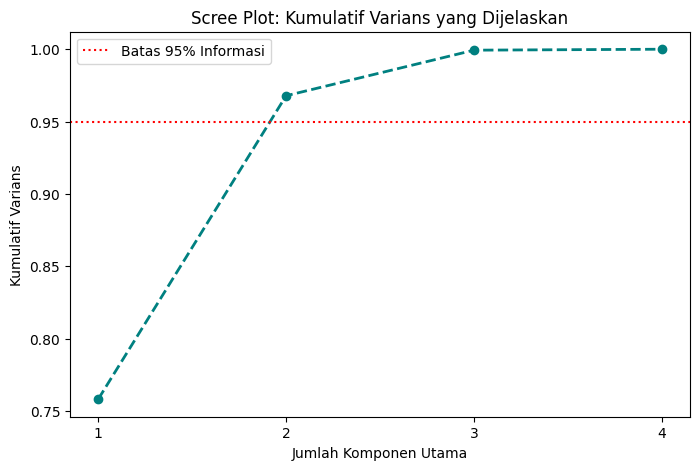

In [2]:
# Simulasi data metrik finansial yang saling berkorelasi
np.random.seed(42)
pendapatan = np.random.normal(5000, 1500, 200)
pengeluaran = pendapatan * 0.7 + np.random.normal(0, 500, 200)
tabungan = pendapatan - pengeluaran + np.random.normal(0, 100, 200)
limit_kartu = pendapatan * 1.5 + np.random.normal(0, 1000, 200)

df_finansial = pd.DataFrame({
    'Pendapatan': pendapatan,
    'Pengeluaran': pengeluaran,
    'Tabungan': tabungan,
    'Limit_Kredit': limit_kartu
})

# 1. Standarisasi Fitur
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_finansial)

# 2. Eksekusi PCA
pca = PCA()
pca.fit(df_scaled)

varians_rasio = pca.explained_variance_ratio_
print("Proporsi Varians yang Dijelaskan oleh setiap Komponen Utama:")
print(np.round(varians_rasio, 4))

# 3. Visualisasi Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 5), varians_rasio.cumsum(), marker='o', linestyle='dashed', color='teal', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='dotted', label='Batas 95% Informasi')
plt.title('Scree Plot: Kumulatif Varians yang Dijelaskan')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Kumulatif Varians')
plt.xticks(range(1, 5))
plt.legend()
plt.show()


***
## 2. Klastering K-Means dan Metode Elbow

### Penjelasan Teori

K-Means adalah algoritma klastering paling populer yang bertujuan untuk mempartisi data ke dalam sejumlah K kelompok yang saling eksklusif. Algoritma ini bekerja secara iteratif:
1. Memilih K titik acak sebagai pusat klaster awal (centroid).
2. Menempatkan setiap observasi ke centroid terdekat (biasanya diukur dengan Jarak Euclidean).
3. Menghitung ulang posisi centroid dengan mengambil nilai rata-rata dari semua observasi di dalam klaster tersebut.
4. Mengulangi langkah kedua dan ketiga hingga posisi centroid tidak lagi berubah secara signifikan.

Salah satu kelemahan K-Means adalah kita harus menentukan nilai K di awal. Kita dapat menggunakan metode Elbow dengan menghitung Inersia (Within-Cluster Sum of Squares) untuk berbagai nilai K. Titik di mana kurva mulai melandai secara drastis seperti siku lengan (elbow) dianggap sebagai K yang paling optimal.

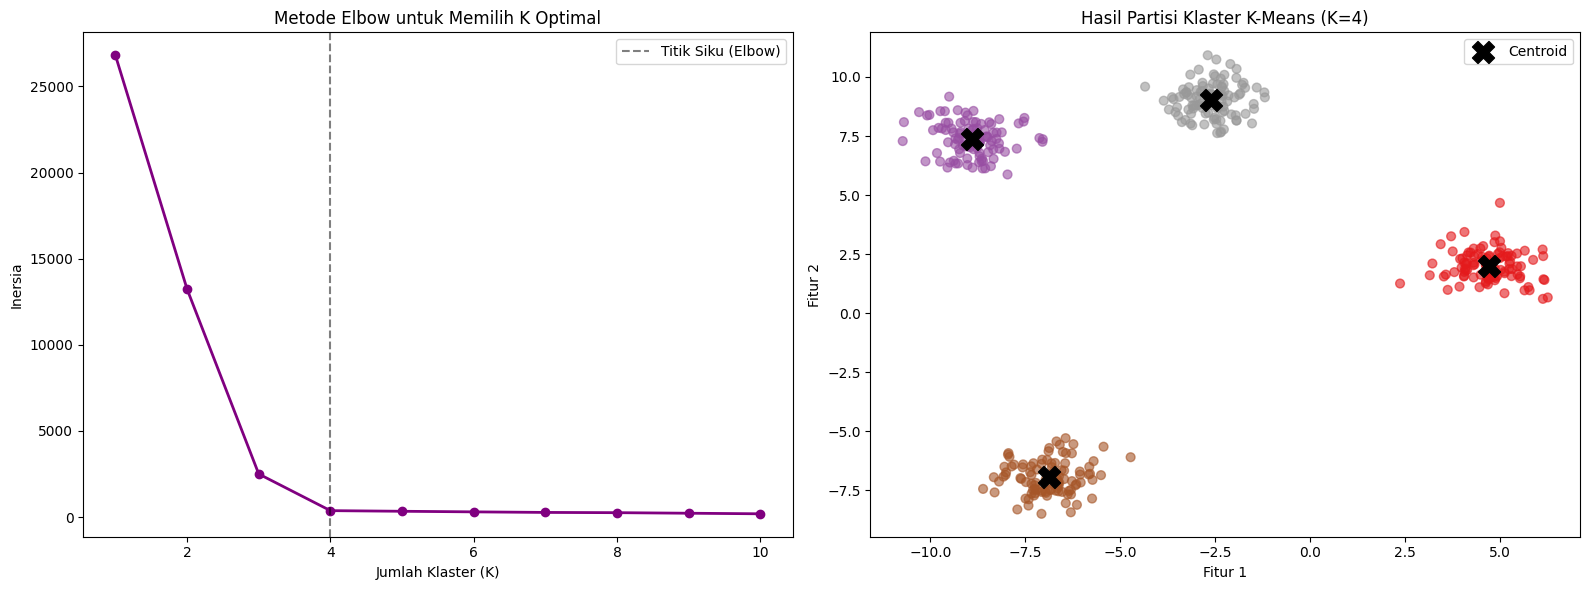

In [3]:
# Membuat data klaster sintetis berupa gumpalan (blobs)
X_kmeans, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.70, random_state=42)
df_kmeans = pd.DataFrame(X_kmeans, columns=['Fitur_1', 'Fitur_2'])

# Mencari nilai K optimal dengan metode Elbow
inertia_list = []
rentang_k = range(1, 11)

for k in rentang_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_kmeans)
    inertia_list.append(kmeans_temp.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Metode Elbow
axes[0].plot(rentang_k, inertia_list, marker='o', color='purple', linewidth=2)
axes[0].set_title('Metode Elbow untuk Memilih K Optimal')
axes[0].set_xlabel('Jumlah Klaster (K)')
axes[0].set_ylabel('Inersia')
axes[0].axvline(x=4, color='black', linestyle='dashed', alpha=0.5, label='Titik Siku (Elbow)')
axes[0].legend()

# Aplikasi K-Means dengan K yang tepat (K=4)
kmeans_final = KMeans(n_clusters=4, random_state=42)
label_kmeans = kmeans_final.fit_predict(X_kmeans)
centroid = kmeans_final.cluster_centers_

# Visualisasi Hasil Klastering
axes[1].scatter(df_kmeans['Fitur_1'], df_kmeans['Fitur_2'], c=label_kmeans, cmap='Set1', s=40, alpha=0.6)
axes[1].scatter(centroid[:, 0], centroid[:, 1], c='black', s=250, marker='X', label='Centroid')
axes[1].set_title('Hasil Partisi Klaster K-Means (K=4)')
axes[1].set_xlabel('Fitur 1')
axes[1].set_ylabel('Fitur 2')
axes[1].legend()

plt.tight_layout()
plt.show()


***
## 3. Klastering Hierarki (Hierarchical Clustering)

### Penjelasan Teori

Metode hierarki sangat berguna ketika kita ingin melihat tingkatan struktur klaster dan kita belum tahu pasti berapa banyak klaster yang dibutuhkan. Pendekatan aglomeratif bekerja dari bawah ke atas:
Setiap titik data awalnya dianggap sebagai satu klaster mandiri. Algoritma kemudian mencari dua klaster yang paling berdekatan dan menggabungkannya. Proses ini diulangi terus menerus hingga seluruh data bergabung menjadi satu klaster besar tunggal.

Seluruh proses penggabungan ini dicatat dan divisualisasikan menggunakan diagram pohon yang disebut Dendrogram. Ketinggian dari garis vertikal pada dendrogram mewakili jarak antar klaster yang digabungkan. Kita bisa memotong pohon tersebut pada ketinggian tertentu untuk mendapatkan jumlah klaster akhir.

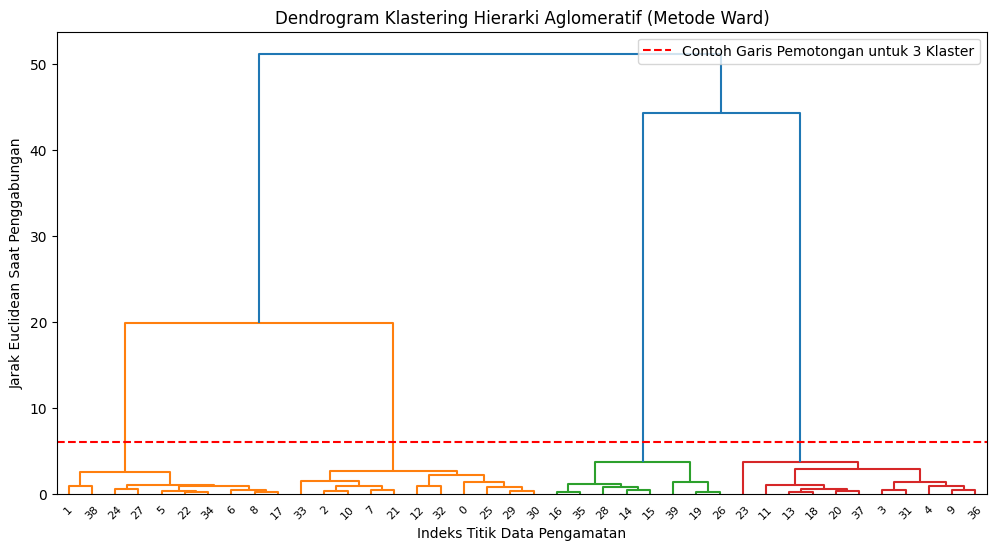

Distribusi anggota masing-masing klaster untuk 40 titik data awal:
0    21
1    11
2     8
Name: count, dtype: int64


In [4]:
# Kita mengambil sub-sampel kecil dari data (40 titik saja) agar dendrogram bisa dibaca dengan mata manusia
X_hierarki = X_kmeans[:40]

plt.figure(figsize=(12, 6))
# Metode Ward berupaya meminimalkan varians di dalam klaster saat melakukan penggabungan
dendrogram = sch.dendrogram(sch.linkage(X_hierarki, method='ward'))
plt.title('Dendrogram Klastering Hierarki Aglomeratif (Metode Ward)')
plt.xlabel('Indeks Titik Data Pengamatan')
plt.ylabel('Jarak Euclidean Saat Penggabungan')
plt.axhline(y=6, color='red', linestyle='dashed', label='Contoh Garis Pemotongan untuk 3 Klaster')
plt.legend()
plt.show()

# Melakukan prediksi pemotongan dengan Scikit-Learn (Pemotongan menjadi 3 klaster)
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
label_hc = hc_model.fit_predict(X_hierarki)

print("Distribusi anggota masing-masing klaster untuk 40 titik data awal:")
print(pd.Series(label_hc).value_counts())


***
## 4. Klastering Berbasis Model (Gaussian Mixture Models)

### Penjelasan Teori

K-Means memiliki masalah yang signifikan saat menangani klaster yang memiliki bentuk lonjong (elips) atau klaster yang saling tumpang tindih. Hal ini karena K-Means secara fundamental berasumsi bahwa setiap klaster berbentuk bulat (sferis) yang simetris.

Gaussian Mixture Models (GMM) menyelesaikan ini dengan pendekatan probabilitas matematis. GMM mengasumsikan bahwa data dibangkitkan dari campuran beberapa distribusi normal (Gaussian). Alih-alih menerapkan keputusan mutlak (hard clustering) di mana sebuah observasi hanya bisa masuk ke satu grup, GMM menggunakan penugasan lunak (soft clustering). Model ini menghitung persentase probabilitas seberapa mungkin sebuah data masuk ke Klaster A dibandingkan Klaster B.

Probabilitas keanggotaan klaster untuk 3 titik data pertama:
[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


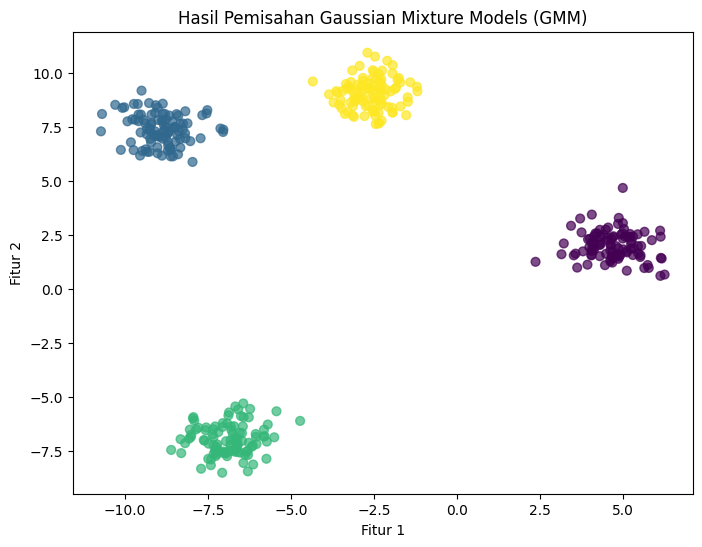

Berbeda dengan K-Means, algoritma GMM mempertimbangkan kovarians matriks, sehingga mampu beradaptasi dengan bentuk klaster yang memanjang atau lonjong.


In [5]:
# Inisialisasi dan pelatihan Gaussian Mixture Model
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X_kmeans)

# Mendapatkan tebakan klaster akhir dan probabilitas lunaknya
label_gmm = gmm.predict(X_kmeans)
probabilitas_gmm = gmm.predict_proba(X_kmeans)

print("Probabilitas keanggotaan klaster untuk 3 titik data pertama:")
print(np.round(probabilitas_gmm[:3], 4))

plt.figure(figsize=(8, 6))
plt.scatter(df_kmeans['Fitur_1'], df_kmeans['Fitur_2'], c=label_gmm, cmap='viridis', s=40, alpha=0.7)
plt.title('Hasil Pemisahan Gaussian Mixture Models (GMM)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

print("Berbeda dengan K-Means, algoritma GMM mempertimbangkan kovarians matriks, sehingga mampu beradaptasi dengan bentuk klaster yang memanjang atau lonjong.")
